In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np

In [5]:
# Create a 2D grid graph (you can also use other graph types)
# Using a 6x6 grid for better visualization
G = nx.grid_2d_graph(20, 20)

# Assign random numbers to each node
random.seed(400)  # For reproducibility
node_values = {node: random.uniform(0, 100) for node in G.nodes()}
nx.set_node_attributes(G, node_values, 'value')

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Graph created with 400 nodes and 760 edges


In [6]:
# Find local minima
# A node is a local minimum if its value is less than all its neighbors' values
local_minima = []

for node in G.nodes():
    node_value = node_values[node]
    neighbors = list(G.neighbors(node))
    
    # Check if current node value is less than all neighbors
    is_local_min = all(node_value < node_values[neighbor] for neighbor in neighbors)
    
    if is_local_min:
        local_minima.append(node)

print(f"Found {len(local_minima)} local minima:")
for node in local_minima:
    print(f"  Node {node}: value = {node_values[node]:.2f}")

Found 82 local minima:
  Node (0, 8): value = 54.71
  Node (0, 11): value = 21.23
  Node (0, 16): value = 4.47
  Node (0, 19): value = 0.63
  Node (1, 1): value = 22.88
  Node (1, 4): value = 9.86
  Node (1, 7): value = 59.65
  Node (1, 13): value = 6.06
  Node (2, 5): value = 28.35
  Node (2, 8): value = 27.72
  Node (2, 12): value = 16.72
  Node (2, 17): value = 15.17
  Node (3, 0): value = 7.60
  Node (3, 2): value = 27.95
  Node (4, 4): value = 2.63
  Node (4, 6): value = 3.48
  Node (4, 9): value = 5.99
  Node (4, 15): value = 20.73
  Node (5, 2): value = 5.47
  Node (5, 19): value = 14.88
  Node (6, 0): value = 24.91
  Node (6, 4): value = 4.63
  Node (6, 9): value = 10.41
  Node (6, 12): value = 7.85
  Node (6, 14): value = 14.90
  Node (6, 16): value = 23.94
  Node (7, 3): value = 29.34
  Node (7, 6): value = 13.85
  Node (7, 8): value = 67.61
  Node (7, 17): value = 5.25
  Node (8, 0): value = 18.84
  Node (8, 2): value = 62.41
  Node (8, 5): value = 14.48
  Node (8, 7): value

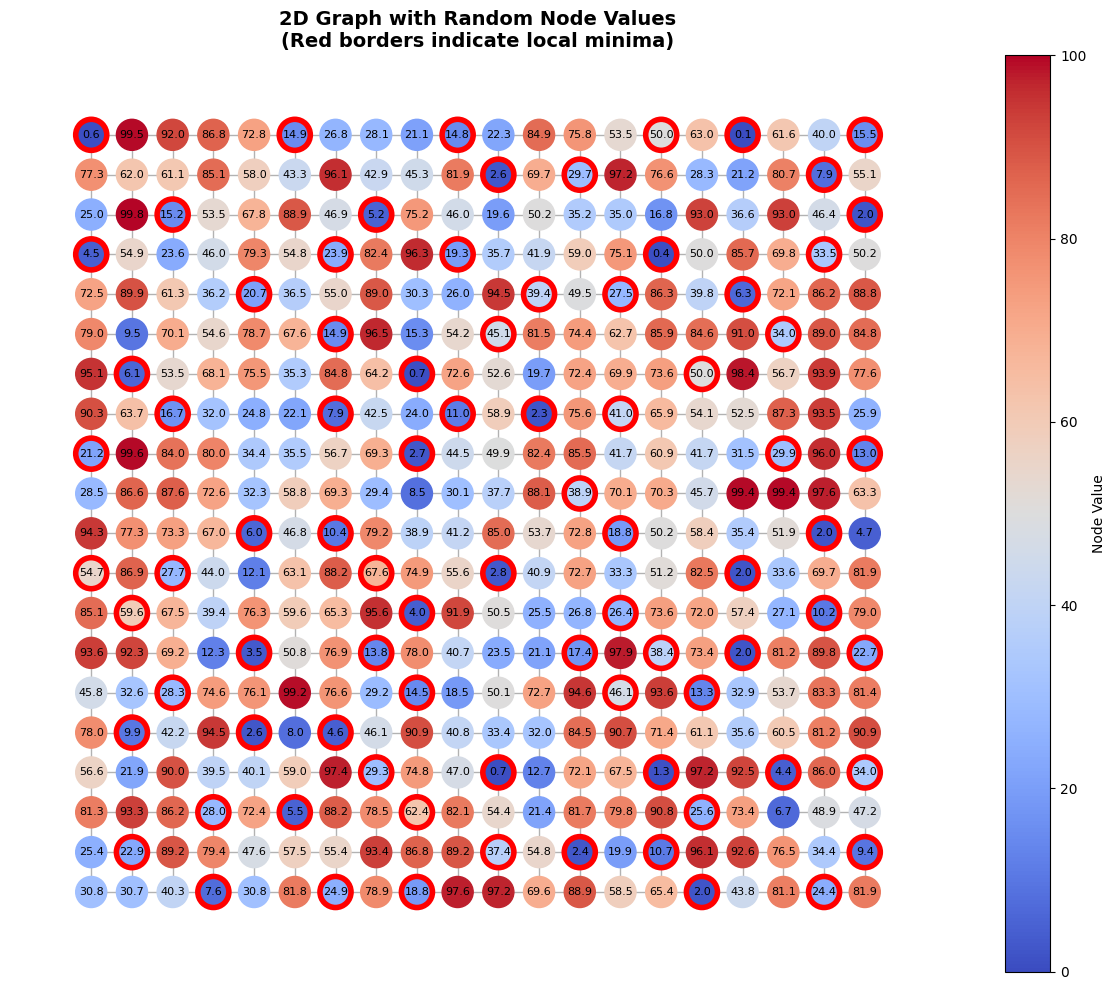


Local minima are highlighted with red borders


In [7]:
# Visualize the graph
fig, ax = plt.subplots(figsize=(12, 10))

# Position nodes in 2D space (grid layout)
pos = {node: node for node in G.nodes()}

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)

# Draw all nodes with colors based on their values
node_colors = [node_values[node] for node in G.nodes()]
nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                                node_size=500, cmap='coolwarm', 
                                vmin=0, vmax=100, ax=ax)

# Highlight local minima with a red border
if local_minima:
    nx.draw_networkx_nodes(G, pos, nodelist=local_minima, 
                           node_size=500, node_color='none',
                           edgecolors='red', linewidths=4, ax=ax)

# Add labels showing the values
labels = {node: f'{node_values[node]:.1f}' for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8, ax=ax)

# Add colorbar
plt.colorbar(nodes, ax=ax, label='Node Value')

# Add title and legend
plt.title('2D Graph with Random Node Values\n(Red borders indicate local minima)', 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nLocal minima are highlighted with red borders")

In [8]:
# Create a random graph with random positions
# Using Erdős-Rényi random graph
n_nodes = 50
p_edge = 0.15  # Probability of edge creation

G_random = nx.erdos_renyi_graph(n_nodes, p_edge, seed=42)

# Assign random values to each node
random.seed(400)
node_values_random = {node: random.uniform(0, 100) for node in G_random.nodes()}
nx.set_node_attributes(G_random, node_values_random, 'value')

# Generate random positions for nodes
random.seed(42)
pos_random = {node: (random.uniform(0, 10), random.uniform(0, 10)) for node in G_random.nodes()}

print(f"Random graph created with {G_random.number_of_nodes()} nodes and {G_random.number_of_edges()} edges")

Random graph created with 50 nodes and 179 edges


In [9]:
# Find local minima in the random graph
local_minima_random = []

for node in G_random.nodes():
    node_value = node_values_random[node]
    neighbors = list(G_random.neighbors(node))
    
    # Skip isolated nodes (nodes with no neighbors)
    if not neighbors:
        continue
    
    # Check if current node value is less than all neighbors
    is_local_min = all(node_value < node_values_random[neighbor] for neighbor in neighbors)
    
    if is_local_min:
        local_minima_random.append(node)

print(f"Found {len(local_minima_random)} local minima:")
for node in local_minima_random:
    print(f"  Node {node}: value = {node_values_random[node]:.2f}")

Found 8 local minima:
  Node 1: value = 25.38
  Node 10: value = 28.49
  Node 16: value = 4.47
  Node 19: value = 0.63
  Node 23: value = 21.89
  Node 33: value = 6.06
  Node 34: value = 9.53
  Node 48: value = 27.72


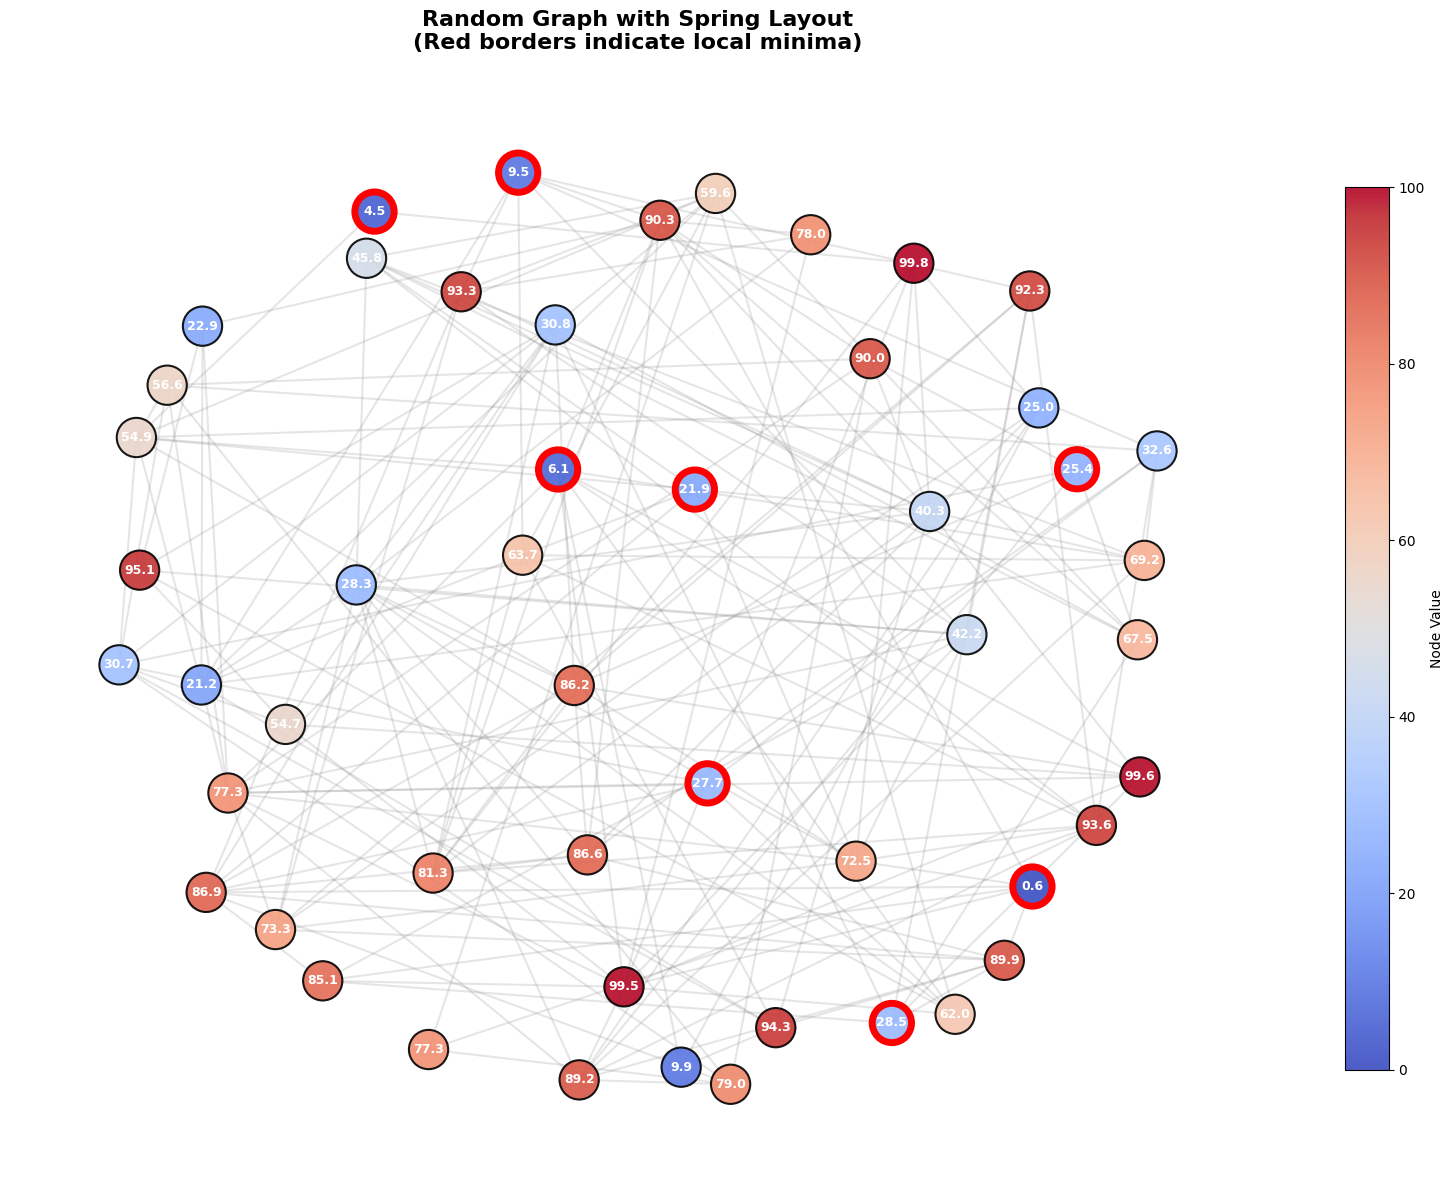


Local minima are highlighted with red borders
Using spring layout for better node distribution


In [11]:
# Visualize the random graph with improved layout
fig_random, ax_random = plt.subplots(figsize=(16, 12))

# Use spring layout for better node distribution
pos_spring = nx.spring_layout(G_random, k=2, iterations=50, seed=42)

# Draw edges with better styling
nx.draw_networkx_edges(G_random, pos_spring, alpha=0.2, width=1.5, edge_color='gray', ax=ax_random)

# Draw all nodes with colors based on their values
node_colors_random = [node_values_random[node] for node in G_random.nodes()]
nodes_random = nx.draw_networkx_nodes(G_random, pos_spring, node_color=node_colors_random, 
                                       node_size=800, cmap='coolwarm', 
                                       vmin=0, vmax=100, ax=ax_random, alpha=0.9,
                                       edgecolors='black', linewidths=1.5)

# Highlight local minima with a thick red border
if local_minima_random:
    nx.draw_networkx_nodes(G_random, pos_spring, nodelist=local_minima_random, 
                           node_size=800, node_color='none',
                           edgecolors='red', linewidths=5, ax=ax_random)

# Add labels showing the values
labels_random = {node: f'{node_values_random[node]:.1f}' for node in G_random.nodes()}
nx.draw_networkx_labels(G_random, pos_spring, labels_random, font_size=9, 
                       font_weight='bold', font_color='white', ax=ax_random)

# Add colorbar with better formatting
cbar = plt.colorbar(nodes_random, ax=ax_random, label='Node Value', shrink=0.8)
cbar.ax.tick_params(labelsize=10)

# Add title and legend
plt.title('Random Graph with Spring Layout\n(Red borders indicate local minima)', 
          fontsize=16, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nLocal minima are highlighted with red borders")
print(f"Using spring layout for better node distribution")

# Real data

In [20]:
import pickle
import xarray as xr
import networkx as nx
import matplotlib.pyplot as plt

In [39]:
output_path = "../data/multilevel_graph_hierarchy.domain03.connected.pkl"
with open(output_path, 'rb') as f:
    loaded_levels = pickle.load(f)

pred = xr.open_dataset("../evals/rain_mse.zarr", engine="zarr")
t_2m = pred.isel(start_time=0, elapsed_forecast_duration=0).sel(state_feature='t_2m')
t_2m = t_2m.rename({'grid_index': 'cell'})
rr = pred.isel(start_time=0, elapsed_forecast_duration=0).sel(state_feature='rain_gsp_rate')
rr = rr.rename({'grid_index': 'cell'})

In [48]:
level = 6
G_coarse = loaded_levels[level]['graph']
level_cells = list(G_coarse.nodes.keys())
coarse_positions = loaded_levels[level]['pos']

In [49]:
coarsen = level
level_data_t_2m = t_2m.state.values.reshape(-1, 4**coarsen).mean(axis=-1)
assert len(level_data_t_2m) == len(level_cells)
nx.set_node_attributes(G_coarse, dict(zip(level_cells, level_data_t_2m)), 't_2m')

level_data_rr = rr.state.values.reshape(-1, 4**coarsen).mean(axis=-1)
assert len(level_data_rr) == len(level_cells)
nx.set_node_attributes(G_coarse, dict(zip(level_cells, level_data_rr)), 'rain_gsp_rate')

In [50]:
import operator

def find_local_extrema(G, attribute='value', comparison_func=operator.lt):
    """
    Find local extrema (minima or maxima) in a graph based on a node attribute.
    
    A node is a local extremum if it satisfies the comparison function
    against all of its neighbors' values.
    
    Parameters
    ----------
    G : nx.Graph
        NetworkX graph with nodes containing the specified attribute
    attribute : str, optional
        Name of the node attribute to use for comparison (default: 'value')
    comparison_func : callable, optional
        Comparison function to use. Default is operator.lt (less than) for minima.
        Use operator.gt (greater than) for maxima.
        Function should take (node_value, neighbor_value) and return bool.
    
    Returns
    -------
    extrema : list
        List of nodes that are local extrema
        
    Examples
    --------
    >>> # Find local minima
    >>> minima = find_local_extrema(G, 't_2m', operator.lt)
    >>> # Find local maxima
    >>> maxima = find_local_extrema(G, 't_2m', operator.gt)
    """
    extrema = []
    
    for node in G.nodes():
        node_value = G.nodes[node].get(attribute)
        
        # Skip nodes without the attribute
        if node_value is None:
            continue
            
        neighbors = list(G.neighbors(node))
        
        # Skip isolated nodes
        if not neighbors:
            continue
        
        # Check if current node satisfies the comparison against all neighbors
        is_extremum = all(
            comparison_func(node_value, G.nodes[neighbor].get(attribute, float('inf'))) 
            for neighbor in neighbors
        )
        
        if is_extremum:
            extrema.append(node)
    
    return extrema


# Convenience functions for common use cases
def find_local_minima(G, attribute='value'):
    """Find local minima. Shorthand for find_local_extrema with operator.lt"""
    return find_local_extrema(G, attribute, operator.lt)


def find_local_maxima(G, attribute='value'):
    """Find local maxima. Shorthand for find_local_extrema with operator.gt"""
    return find_local_extrema(G, attribute, operator.gt)

In [51]:
# Find local minima and maxima for both t_2m and rain_gsp_rate
local_minima_t2m = find_local_minima(G_coarse, attribute='t_2m')
local_maxima_rain = find_local_maxima(G_coarse, attribute='rain_gsp_rate')

print("Temperature (t_2m):")
print(f"  Local minima: {len(local_minima_t2m)}")
print("\nRain (rain_gsp_rate):")
print(f"  Local maxima: {len(local_maxima_rain)}")

Temperature (t_2m):
  Local minima: 24

Rain (rain_gsp_rate):
  Local maxima: 29


In [55]:
# Calculate overlap score: fraction of t_2m minima that match rain maxima
# Convert to sets for efficient intersection
minima_t2m_set = set(local_minima_t2m)
maxima_rain_set = set(local_maxima_rain)

# Find matching cells (nodes that are both cold spots AND rain maxima)
matching_cells = minima_t2m_set.intersection(maxima_rain_set)

# Calculate individual scores
if len(local_minima_t2m) > 0:
    score_from_t2m = len(matching_cells) / len(local_minima_t2m)
else:
    score_from_t2m = 0.0

if len(local_maxima_rain) > 0:
    score_from_rain = len(matching_cells) / len(local_maxima_rain)
else:
    score_from_rain = 0.0

# Calculate joint scores
# Harmonic mean (F1-score): balanced measure of both precisions
if score_from_t2m + score_from_rain > 0:
    f1_score = 2 * (score_from_t2m * score_from_rain) / (score_from_t2m + score_from_rain)
else:
    f1_score = 0.0

# Jaccard similarity: matches / union
total_unique = len(minima_t2m_set.union(maxima_rain_set))
jaccard_score = len(matching_cells) / total_unique if total_unique > 0 else 0.0

# Arithmetic mean: simple average
mean_score = (score_from_t2m + score_from_rain) / 2

print("\n" + "="*60)
print("OVERLAP ANALYSIS: Cold Spots (t_2m min) vs Rain Peaks (rain max)")
print("="*60)
print(f"Total t_2m minima (cold spots):     {len(local_minima_t2m)}")
print(f"Total rain maxima (rain peaks):     {len(local_maxima_rain)}")
print(f"Matching cells (intersection):      {len(matching_cells)}")
print(f"Total unique extrema (union):       {total_unique}")
print(f"\nIndividual Scores:")
print(f"  Matches / t_2m minima:            {score_from_t2m:.2%}")
print(f"  Matches / rain maxima:            {score_from_rain:.2%}")
print(f"\nJoint Scores:")
print(f"  F1-Score (harmonic mean):         {f1_score:.2%}")
print(f"  Jaccard similarity:               {jaccard_score:.2%}")
print(f"  Arithmetic mean:                  {mean_score:.2%}")
print("="*60)

if matching_cells:
    print(f"\nMatching cell IDs: {sorted(list(matching_cells))[:10]}{'...' if len(matching_cells) > 10 else ''}")


OVERLAP ANALYSIS: Cold Spots (t_2m min) vs Rain Peaks (rain max)
Total t_2m minima (cold spots):     24
Total rain maxima (rain peaks):     29
Matching cells (intersection):      12
Total unique extrema (union):       41

Individual Scores:
  Matches / t_2m minima:            50.00%
  Matches / rain maxima:            41.38%

Joint Scores:
  F1-Score (harmonic mean):         45.28%
  Jaccard similarity:               29.27%
  Arithmetic mean:                  45.69%

Matching cell IDs: [3962997, 3999861, 4028533, 4032629, 4114549, 11267459, 11292035, 11341187, 11353475, 11378051]...


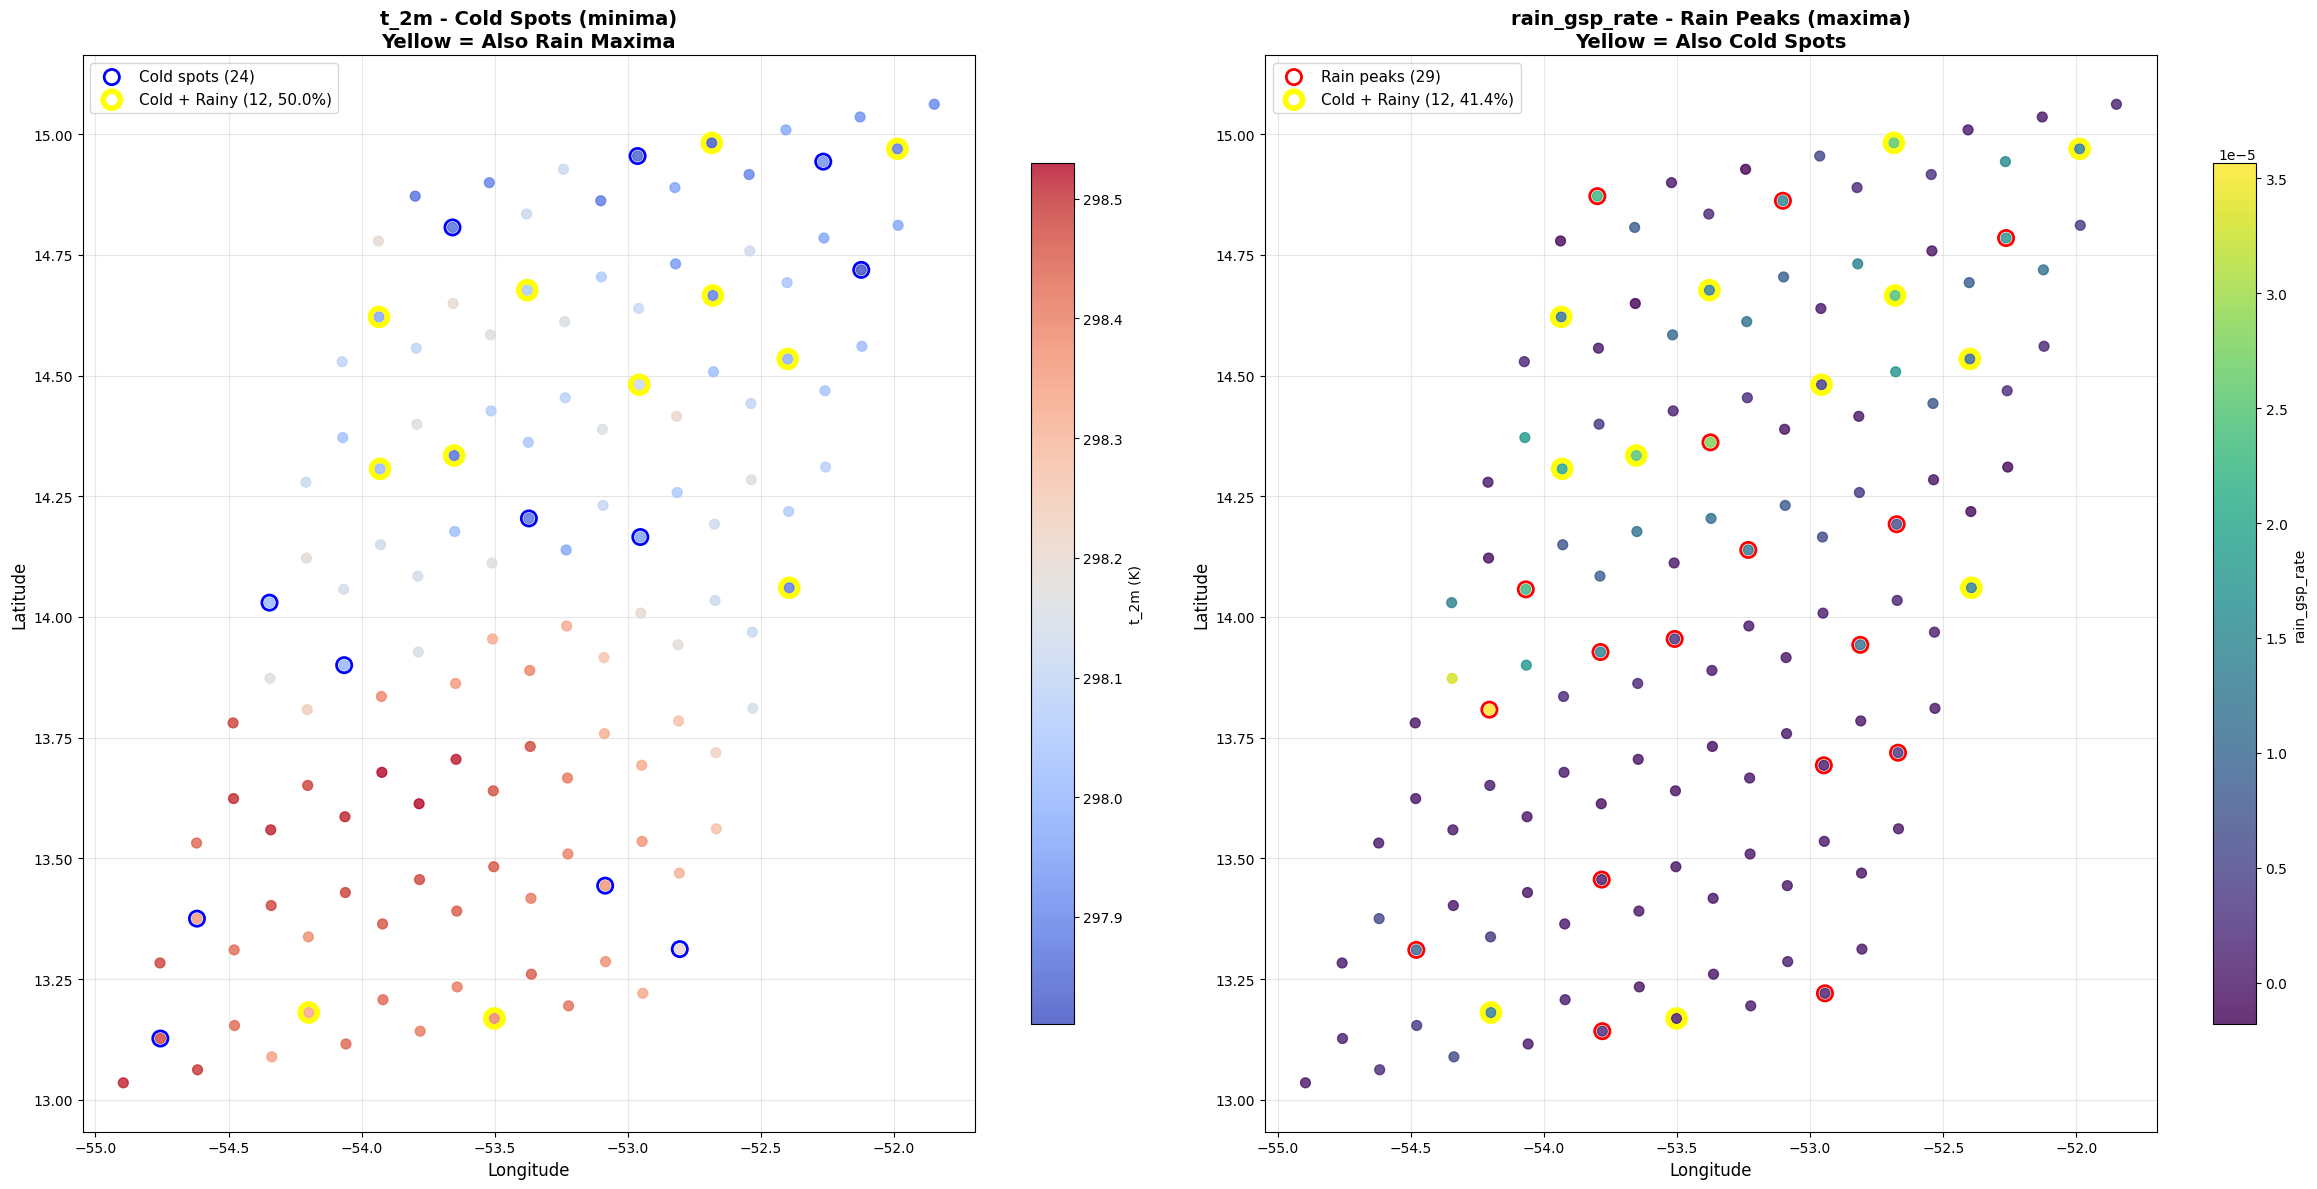

In [56]:
# Visualize t_2m minima and rain maxima with matching cells highlighted
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))

# Prepare position data
lons = [coarse_positions[node][0] for node in G_coarse.nodes()]
lats = [coarse_positions[node][1] for node in G_coarse.nodes()]

# --- Left: t_2m with minima ---
node_colors_t2m = [G_coarse.nodes[node]['t_2m'] for node in G_coarse.nodes()]
vmin_t2m = min(node_colors_t2m)
vmax_t2m = max(node_colors_t2m)

scatter1 = ax1.scatter(lons, lats, c=node_colors_t2m, s=50, 
                       cmap='coolwarm', vmin=vmin_t2m, vmax=vmax_t2m, 
                       alpha=0.8, zorder=2)

# Highlight all t_2m minima in blue
if local_minima_t2m:
    minima_lons_t2m = [coarse_positions[node][0] for node in local_minima_t2m]
    minima_lats_t2m = [coarse_positions[node][1] for node in local_minima_t2m]
    ax1.scatter(minima_lons_t2m, minima_lats_t2m, s=120, 
               facecolors='none', edgecolors='blue', linewidths=2, zorder=3,
               label=f'Cold spots ({len(local_minima_t2m)})')

# Highlight matching cells (both cold AND rainy) in yellow/gold
if matching_cells:
    match_lons = [coarse_positions[node][0] for node in matching_cells]
    match_lats = [coarse_positions[node][1] for node in matching_cells]
    ax1.scatter(match_lons, match_lats, s=150, 
               facecolors='none', edgecolors='yellow', linewidths=4, zorder=4,
               label=f'Cold + Rainy ({len(matching_cells)}, {score_from_t2m:.1%})')

cbar1 = plt.colorbar(scatter1, ax=ax1, label='t_2m (K)', shrink=0.8)
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.set_title(f't_2m - Cold Spots (minima)\nYellow = Also Rain Maxima', 
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, alpha=0.3)

# --- Right: rain with maxima ---
node_colors_rain = [G_coarse.nodes[node]['rain_gsp_rate'] for node in G_coarse.nodes()]
vmin_rain = min(node_colors_rain)
vmax_rain = max(node_colors_rain)

scatter2 = ax2.scatter(lons, lats, c=node_colors_rain, s=50, 
                       cmap='viridis', vmin=vmin_rain, vmax=vmax_rain, 
                       alpha=0.8, zorder=2)

# Highlight all rain maxima in red
if local_maxima_rain:
    maxima_lons_rain = [coarse_positions[node][0] for node in local_maxima_rain]
    maxima_lats_rain = [coarse_positions[node][1] for node in local_maxima_rain]
    ax2.scatter(maxima_lons_rain, maxima_lats_rain, s=120, 
               facecolors='none', edgecolors='red', linewidths=2, zorder=3,
               label=f'Rain peaks ({len(local_maxima_rain)})')

# Highlight matching cells in yellow/gold
if matching_cells:
    match_lons = [coarse_positions[node][0] for node in matching_cells]
    match_lats = [coarse_positions[node][1] for node in matching_cells]
    ax2.scatter(match_lons, match_lats, s=150, 
               facecolors='none', edgecolors='yellow', linewidths=4, zorder=4,
               label=f'Cold + Rainy ({len(matching_cells)}, {score_from_rain:.1%})')

cbar2 = plt.colorbar(scatter2, ax=ax2, label='rain_gsp_rate', shrink=0.8)
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.set_title(f'rain_gsp_rate - Rain Peaks (maxima)\nYellow = Also Cold Spots', 
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=11, loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()